In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# load my dataset
file_path = r"D:\Python_For_DataScience\Stat\assignment\nepal_student_performance.csv"
df = pd.read_csv(file_path)

print(df.shape)
print(df.dtypes)

(1200, 11)
student_id          int64
age                 int64
study_hours       float64
sleep_hours       float64
attendance_pct    float64
family_income     float64
location_type         str
stream                str
has_tuition           str
exam_score        float64
result                str
dtype: object


Split into two groups and look at basic stats

In [3]:
# make two separate groups based on tuition status
tuition_yes = df[df["has_tuition"] == "Yes"]
tuition_no = df[df["has_tuition"] == "No"]

# pull out just the exam_score column from each group
scores_yes = tuition_yes["exam_score"]
scores_no = tuition_no["exam_score"]

print("Group with tuition:")
print("count =", len(scores_yes))
print("mean =", round(scores_yes.mean(), 2))
print("median =", round(scores_yes.median(), 2))
print("std =", round(scores_yes.std(), 2))

print()

print("Group with no tuition:")
print("count =", len(scores_no))
print("mean =", round(scores_no.mean(), 2))
print("median =", round(scores_no.median(), 2))
print("std =", round(scores_no.std(), 2))

Group with tuition:
count = 636
mean = 56.15
median = 54.45
std = 13.64

Group with no tuition:
count = 564
mean = 49.72
median = 49.1
std = 13.02


Boxplot and histogram of the two groups

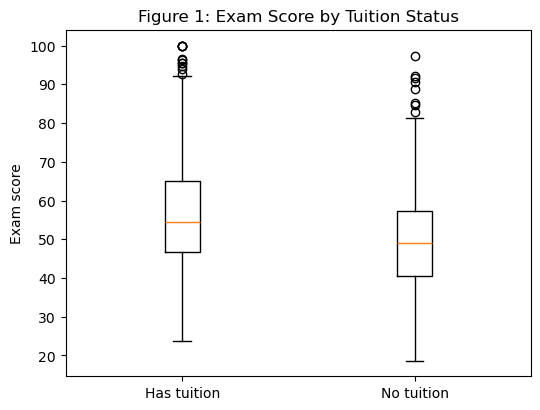

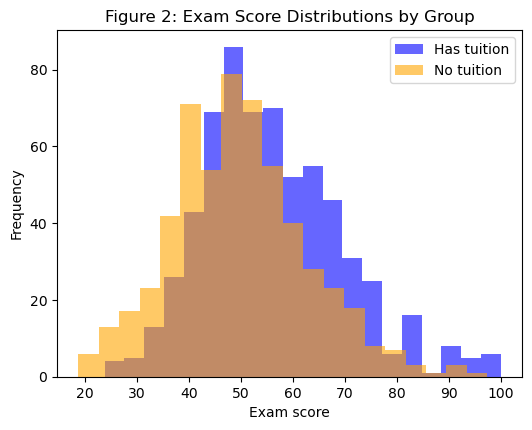

In [4]:
plt.figure(figsize=(6, 4.5))
plt.boxplot([scores_yes, scores_no], tick_labels=["Has tuition", "No tuition"])
plt.title("Figure 1: Exam Score by Tuition Status")
plt.ylabel("Exam score")
plt.show()

plt.figure(figsize=(6, 4.5))
plt.hist(scores_yes, bins=20, alpha=0.6, label="Has tuition", color="blue")
plt.hist(scores_no, bins=20, alpha=0.6, label="No tuition", color="orange")
plt.title("Figure 2: Exam Score Distributions by Group")
plt.xlabel("Exam score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Check the assumptions (normality, equal variance, outliers)

In [5]:
# normality test for each group
print("Shapiro-Wilk test for tuition group:")
print(stats.shapiro(scores_yes))

print()
print("Shapiro-Wilk test for no-tuition group:")
print(stats.shapiro(scores_no))

# test if the two groups have equal variance
print()
print("Levene's test for equal variance:")
print(stats.levene(scores_yes, scores_no))

# check for outliers using the 1.5 x IQR rule
q1 = scores_yes.quantile(0.25)
q3 = scores_yes.quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers_yes = scores_yes[(scores_yes < lower_fence) | (scores_yes > upper_fence)]
print()
print("Number of outliers in tuition group:", len(outliers_yes))

q1 = scores_no.quantile(0.25)
q3 = scores_no.quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers_no = scores_no[(scores_no < lower_fence) | (scores_no > upper_fence)]
print("Number of outliers in no-tuition group:", len(outliers_no))

Shapiro-Wilk test for tuition group:
ShapiroResult(statistic=np.float64(0.974260108335857), pvalue=np.float64(3.905777308620127e-09))

Shapiro-Wilk test for no-tuition group:
ShapiroResult(statistic=np.float64(0.9881146459282291), pvalue=np.float64(0.00015198173822341226))

Levene's test for equal variance:
LeveneResult(statistic=np.float64(1.5280449836669843), pvalue=np.float64(0.21664840329593552))

Number of outliers in tuition group: 11
Number of outliers in no-tuition group: 8


Q-Q plots (another way to check normality)

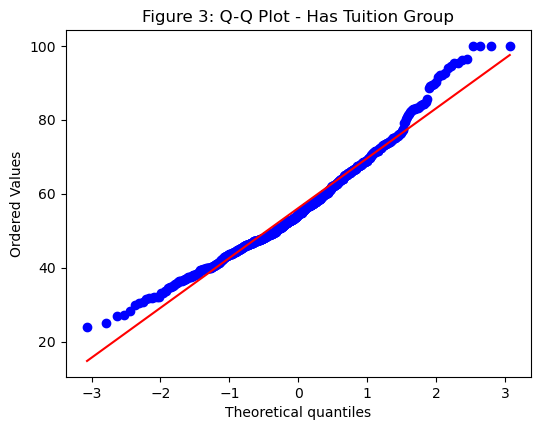

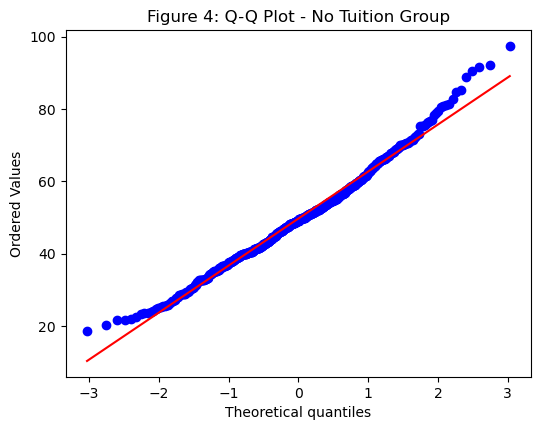

In [6]:
plt.figure(figsize=(6, 4.5))
stats.probplot(scores_yes, dist="norm", plot=plt)
plt.title("Figure 3: Q-Q Plot - Has Tuition Group")
plt.show()

plt.figure(figsize=(6, 4.5))
stats.probplot(scores_no, dist="norm", plot=plt)
plt.title("Figure 4: Q-Q Plot - No Tuition Group")
plt.show()

Run the three group-comparison tests

In [7]:
# independent t-test (assumes equal variance)
t_test_result = stats.ttest_ind(scores_yes, scores_no, equal_var=True)
print("Independent t-test:")
print(t_test_result)

print()

# Welch's t-test (does NOT assume equal variance)
welch_result = stats.ttest_ind(scores_yes, scores_no, equal_var=False)
print("Welch's t-test:")
print(welch_result)

print()

# Mann-Whitney U test (non-parametric, uses ranks)
mw_result = stats.mannwhitneyu(scores_yes, scores_no, alternative="two-sided")
print("Mann-Whitney U test:")
print(mw_result)

Independent t-test:
TtestResult(statistic=np.float64(8.326264976636432), pvalue=np.float64(2.2539561903553114e-16), df=np.float64(1198.0))

Welch's t-test:
TtestResult(statistic=np.float64(8.34937207838649), pvalue=np.float64(1.8839322159113339e-16), df=np.float64(1191.4541072274224))

Mann-Whitney U test:
MannwhitneyuResult(statistic=np.float64(226148.5), pvalue=np.float64(5.709843859453162e-15))


Effect size and confidence interval

In [8]:
n1 = len(scores_yes)
n2 = len(scores_no)

# Cohen's d - how big is the difference, in standard deviation units
pooled_std = np.sqrt(((n1 - 1) * scores_yes.var() + (n2 - 1) * scores_no.var()) / (n1 + n2 - 2))
cohens_d = (scores_yes.mean() - scores_no.mean()) / pooled_std
print("Cohen's d:", round(cohens_d, 4))

# 95% confidence interval for the difference in means
mean_diff = scores_yes.mean() - scores_no.mean()
standard_error = np.sqrt(scores_yes.var() / n1 + scores_no.var() / n2)
degrees_freedom = welch_result.df
t_critical = stats.t.ppf(0.975, degrees_freedom)

lower_bound = mean_diff - t_critical * standard_error
upper_bound = mean_diff + t_critical * standard_error

print("Mean difference:", round(mean_diff, 3))
print("95% confidence interval:", round(lower_bound, 3), "to", round(upper_bound, 3))

# effect size for Mann-Whitney test (rank-biserial correlation)
rank_biserial = 1 - (2 * mw_result.statistic) / (n1 * n2)
print("Rank-biserial correlation:", round(rank_biserial, 4))

Cohen's d: 0.4816
Mean difference: 6.431
95% confidence interval: 4.92 to 7.942
Rank-biserial correlation: -0.2609


Pearson and Spearman correlation (RQ2)

Pearson r: 0.7544
Spearman rho: 0.7179
R-squared: 0.5691
95% confidence interval for r: 0.7289 to 0.7778


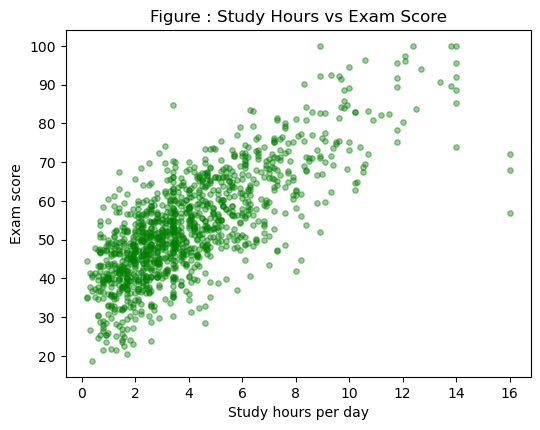

In [10]:
x = df["study_hours"]
y = df["exam_score"]

pearson_r = x.corr(y, method="pearson")
spearman_rho = x.corr(y, method="spearman")

print("Pearson r:", round(pearson_r, 4))
print("Spearman rho:", round(spearman_rho, 4))
print("R-squared:", round(pearson_r ** 2, 4))

# 95% confidence interval for Pearson r (using Fisher z-transformation)
n = len(x)
z_value = np.arctanh(pearson_r)
standard_error_z = 1 / np.sqrt(n - 3)
z_critical = 1.96

lower_z = z_value - z_critical * standard_error_z
upper_z = z_value + z_critical * standard_error_z

lower_r = np.tanh(lower_z)
upper_r = np.tanh(upper_z)

print("95% confidence interval for r:", round(lower_r, 4), "to", round(upper_r, 4))

plt.figure(figsize=(6, 4.5))
plt.scatter(x, y, alpha=0.4, s=15, color="green")
plt.title("Figure : Study Hours vs Exam Score")
plt.xlabel("Study hours per day")
plt.ylabel("Exam score")
plt.show()